In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("placement.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package (as LPA)')

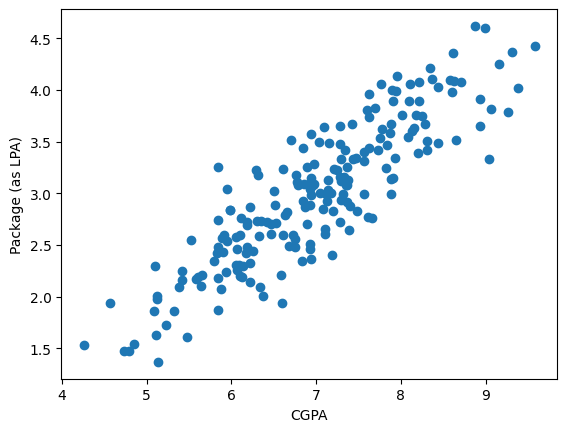

In [4]:
plt.scatter(df["cgpa"],df["package"])
plt.xlabel("CGPA")
plt.ylabel("Package (as LPA)")

In [5]:
x= df.iloc[:,0:1]
y = df.iloc[:,-1]

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=2)

In [7]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [8]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
x_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [10]:
lr.predict(x_test.iloc[0].values.reshape(1,1))

c:\Users\Yash\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

Text(0, 0.5, 'Package (as LPA)')

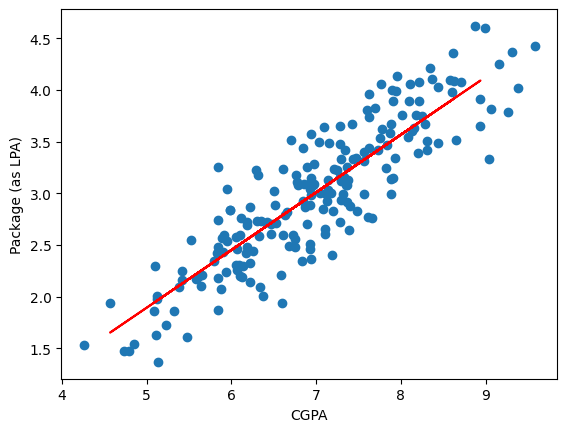

In [11]:
plt.scatter(df["cgpa"],df["package"])
plt.plot(x_test, lr.predict(x_test),color="red")
plt.xlabel("CGPA")
plt.ylabel("Package (as LPA)")

In [12]:
m = lr.coef_

In [13]:
b = lr.intercept_

In [14]:
# y = mx + b
m * 8.58 + b

array([3.89111601])

## Regression metric

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [18]:
y_pred = lr.predict(x_test)

In [21]:
print("MAE :",mean_absolute_error(y_test,y_pred))

MAE : 0.2884710931878175


In [22]:
print("MSE :",mean_squared_error(y_test,y_pred))


MSE : 0.12129235313495527


In [23]:
print("RMSE :",np.sqrt(mean_squared_error(y_test,y_pred)))


RMSE : 0.34827051717731616


In [24]:
print("R2 :",r2_score(y_test,y_pred))

R2 : 0.780730147510384
